# Избыток экспериментальных событий при отборе нейросетью: что установлено

Документ сводит воедино результаты нескольких недель проверок. Он написан для читателя, который
знаком с экспериментом и с моделированием, но не следил за ходом этого анализа.

**Главное правило этого документа:** рядом с каждым утверждением указано, чем именно оно
измерено и **что из этого измерения не следует**. Несколько выводов, сделанных по ходу работы,
при перепроверке оказались сформулированы шире, чем позволяют данные; они помечены и
переформулированы, а не удалены.

---

## 0. Термины и источники данных

**Классификатор** — нейросеть-трансформер `260816_2250_da_nu_classifier_exp_full_E1_lambda0.01_FIXED_sn256`,
обученная отделять нейтрино от атмосферных мюонов. Вход — последовательность хитов, каждый
описан пятёркой чисел: заряд, время, три координаты модуля. Выход — число от 0 до 1 (**скор**).

**Фильтр sig-noise** — отдельная нейросеть, работающая раньше классификатора: она помечает
каждый хит как сигнальный или шумовой. Классификатор видит только хиты с вероятностью выше 0.8,
посчитанной при размере батча 256. Все «хиты» ниже — сигнальные в этом смысле.

**Отбор качества (h8s3)** — событие берётся в анализ, если у него не меньше 8 сигнальных хитов
и они лежат не меньше чем на 3 струнах.

**Порог классификации ξ** — событие считается «принятым», если скор больше ξ. Рабочая точка
проекта ξ = 0.8, но всё ниже посчитано на сетке порогов, потому что результат от неё зависит.

**Избыток** — отношение доли принятых экспериментальных событий к доле принятых
смоделированных атмосферных мюонов. Обе доли считаются от своего отбора качества.

### Источники

| что | где |
|---|---|
| моделирование атмосферных мюонов | `baikal_mc_merged.h5`, класс `muatm_2020` |
| экспериментальные данные | `exp_full.h5`, 29 ранов сезона 2020, кластеры c02–c07 |
| скоры и эмбеддинги | `preds/<модель>/{mc_merged,exp_full}_thr0p8.duckdb` |
| признаки событий | `features.duckdb`, 79 величин на событие, собран `build_features.py`, `seq_features.py`, `pair_features.py` |

**Исключения.** Из моделирования убраны события, на которых обучалась модель. Из данных убраны
два рана кластера 2 с проверенным дефектом каналов (`config.yaml`, статус `verified`).

### Ограничение, действующее на всё ниже

**Абсолютной нормировки нет.** У мюонного моделирования вес события тождественно равен единице,
и живое время генерации нигде не записано. Поэтому сравнивать можно только **доли**, и любое
утверждение вида «событий столько-то в час» этими данными не проверяется.

In [1]:
import warnings
from pathlib import Path
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
HERE = Path("/home/albert/Baikal2025/inference_v2/nu_classifier/analysis/excess_mechanism")
(HERE / "figures").mkdir(exist_ok=True)
MODEL = "260816_2250_da_nu_classifier_exp_full_E1_lambda0.01_FIXED_sn256@best_da_model"
PREDS = HERE.parents[1] / "preds" / MODEL

db = duckdb.connect(str(HERE / "features.duckdb"), read_only=True)
events = db.execute("SELECT * FROM features").df()

# Скоры лежат в базах предсказаний; тянем их точечно по ключам, а не полным соединением.
score = {}
for src, name in (("mc", "mc_merged_thr0p8.duckdb"), ("exp", "exp_full_thr0p8.duckdb")):
    con = duckdb.connect(str(PREDS / name), read_only=True)
    con.register("_keys", pd.DataFrame({"event_fk": events[events.source == src].event_fk}))
    for fk, s in con.execute("SELECT p.event_fk, p.score FROM predictions p "
                             "JOIN _keys USING (event_fk)").fetchall():
        score[(src, fk)] = s
    con.close()
events["score"] = [score.get((s, k), np.nan) for s, k in zip(events.source, events.event_fk)]
assert events.score.notna().all(), "у части событий нет скора"

# Группы 6 и 8 (принятые при 0.8) взяты целиком, 5 и 7 - квотной выборкой, поэтому нужен вес,
# восстанавливающий полную популяцию.
FULL_SIZE = {5: 23_159_967, 6: 7_751, 7: 3_177_637, 8: 3_044}
events["weight"] = events.group_id.map(
    {k: FULL_SIZE[k] / (events.group_id == k).sum() for k in FULL_SIZE})
mc = events[events.group_id.isin([5, 6])]
exp = events[events.group_id.isin([7, 8])]

BLUE, ORANGE, TEAL, VIOLET = "#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"
INK, MUTED, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
def style(ax):
    ax.set_facecolor(SURFACE); ax.grid(color="#e5e4e0", lw=0.8); ax.set_axisbelow(True)
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    for s in ("left", "bottom"): ax.spines[s].set_color("#c9c8c3")
    ax.tick_params(colors=MUTED, length=0)
    return ax

print(f"{len(events):,} событий с признаками; "
      f"моделирование {len(mc):,}, эксперимент {len(exp):,}")

628,456 событий с признаками; моделирование 207,751, эксперимент 203,044


## 1. Наблюдение, не зависящее ни от какой модели

Здесь только счёт событий: сколько прошло отбор качества и сколько из них принято при каждом
пороге. Никаких поправок, никаких предположений.

In [2]:
THRESHOLDS = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
rows = []
for xi in THRESHOLDS:
    rate_mc = np.average((mc.score > xi).values, weights=mc.weight)
    rate_exp = np.average((exp.score > xi).values, weights=exp.weight)
    rows.append({"порог ξ": xi,
                 "принято в моделировании, %": 100 * rate_mc,
                 "принято в данных, %": 100 * rate_exp,
                 "избыток": rate_exp / rate_mc})
threshold_table = pd.DataFrame(rows)
display(threshold_table.round(4))

BANDS = [(0.0,0.01),(0.01,0.05),(0.05,0.1),(0.1,0.2),(0.2,0.3),
         (0.3,0.5),(0.5,0.7),(0.7,0.9),(0.9,1.01)]
rows = []
for lo, hi in BANDS:
    in_mc = ((mc.score >= lo) & (mc.score < hi)).values
    in_exp = ((exp.score >= lo) & (exp.score < hi)).values
    n_exp = exp.weight.values[in_exp].sum()
    if n_exp < 300:
        continue
    share_mc = np.average(in_mc, weights=mc.weight)
    share_exp = np.average(in_exp, weights=exp.weight)
    rows.append({"полоса скора": f"{lo:.2f}–{hi:.2f}",
                 "событий данных в полосе": int(n_exp),
                 "доля моделирования, %": 100 * share_mc,
                 "доля данных, %": 100 * share_exp,
                 "избыток в полосе": share_exp / share_mc})
band_table = pd.DataFrame(rows)
display(band_table.round(4))

,порог ξ,"принято в моделировании, %","принято в данных, %",избыток
0,0.01,2.4681,3.9615,1.6051
1,0.05,1.1311,1.6742,1.4802
2,0.10,0.7812,1.1477,1.4691
3,0.20,0.4753,0.7486,1.5749
4,0.30,0.3089,0.5513,1.7848
5,0.50,0.1399,0.3115,2.2262
6,0.70,0.0584,0.1591,2.7228
7,0.80,0.0335,0.0957,2.8606
8,0.90,0.0140,0.0436,3.1092
9,0.95,0.0067,0.0230,3.4377


,полоса скора,событий данных в полосе,"доля моделирования, %","доля данных, %",избыток в полосе
0,0.00–0.01,3054678,97.5319,96.0385,0.9847
1,0.01–0.05,72751,1.3371,2.2873,1.7107
2,0.05–0.10,16746,0.3499,0.5265,1.5048
3,0.10–0.20,12694,0.3059,0.3991,1.3047
4,0.20–0.30,6275,0.1664,0.1973,1.1854
5,0.30–0.50,7626,0.1689,0.2398,1.4192
6,0.50–0.70,4845,0.0815,0.1524,1.8700
7,0.70–0.90,3675,0.0444,0.1156,2.6009
8,0.90–1.01,1386,0.0140,0.0436,3.1092


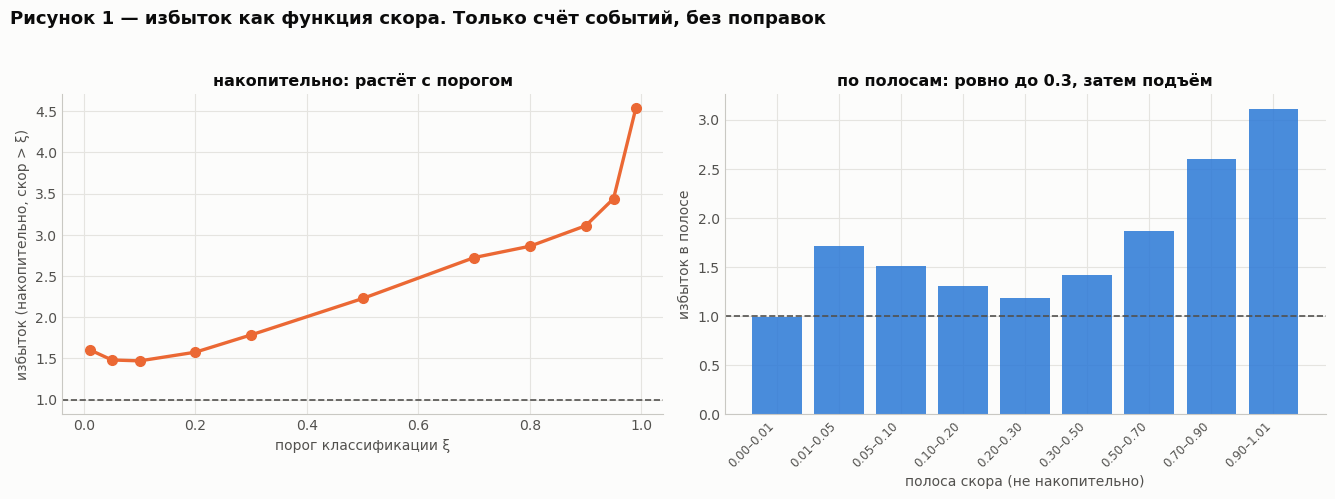

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 4.8)); fig.patch.set_facecolor(SURFACE)
ax = style(axes[0])
ax.plot(threshold_table["порог ξ"], threshold_table["избыток"], "o-", color=ORANGE, lw=2.4, ms=7)
ax.axhline(1.0, color=MUTED, ls="--", lw=1.2)
ax.set_xlabel("порог классификации ξ", color=MUTED)
ax.set_ylabel("избыток (накопительно, скор > ξ)", color=MUTED)
ax.set_title("накопительно: растёт с порогом", fontsize=11.5, fontweight="bold", color=INK)

ax = style(axes[1])
centres = np.arange(len(band_table))
ax.bar(centres, band_table["избыток в полосе"], color=BLUE, alpha=0.85)
ax.axhline(1.0, color=MUTED, ls="--", lw=1.2)
ax.set_xticks(centres)
ax.set_xticklabels(band_table["полоса скора"], rotation=45, ha="right", fontsize=8.5)
ax.set_xlabel("полоса скора (не накопительно)", color=MUTED)
ax.set_ylabel("избыток в полосе", color=MUTED)
ax.set_title("по полосам: ровно до 0.3, затем подъём", fontsize=11.5,
             fontweight="bold", color=INK)
fig.suptitle("Рисунок 1 — избыток как функция скора. Только счёт событий, без поправок",
             x=0.007, ha="left", fontsize=13, fontweight="bold", color=INK, y=1.03)
plt.tight_layout()
plt.savefig(HERE / "figures/summary_observation.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()

**Что здесь установлено.** Избыток существует при любом пороге. Накопительно он растёт от 1.6
при ξ = 0.01 до 4.5 при ξ = 0.99. По полосам видно, что рост не размазан: до скора 0.3 избыток
держится около 1.3–1.7 и даже слегка падает, а выше начинает расти и достигает 3.6.

**Чего здесь не установлено.** Это описание, а не объяснение. Из того, что избыток растёт с
порогом, не следует ни что верхние события «другие», ни что они «настоящие нейтрино». Ниже эти
возможности проверяются по отдельности.

Скрипт: `excess_vs_threshold.py`, `excess_by_band.py`.

## 2. Что классификатор принимает: проверка по истине моделирования

Единственная точка во всём анализе, где известен правильный ответ. В моделировании для каждого
события записан **истинный зенитный угол**, а подгонка трека по хитам его не видит. Сравнение
одного с другим — независимая проверка.

Соглашение об углах: 0° — событие идёт снизу вверх, 90° — горизонт, 180° — сверху вниз.
Атмосферные мюоны рождаются в атмосфере, поэтому их истинный зенит всегда больше 90°.

**Подгонка трека.** Для прямого релятивистского трека время прихода черенковского света
считается точно: `t = t₀ + (s + 0.9364·d)/c`, где `s` — продольная, `d` — поперечная координата
модуля относительно трека. Направление ищется перебором по сетке из 500 направлений с пятью
раундами уточнения; проверено на синтетических треках, построенных по этой же формуле
(`test_features.py`): остаток 0.9–2.3 нс, ошибка направления 0.7–1.9°.

In [4]:
db.execute(f"ATTACH '{PREDS / 'mc_merged_thr0p8.duckdb'}' AS sim (READ_ONLY)")
truth = db.execute('''
    SELECT f.group_id, f.fit_zenith, t.zenith_deg AS true_zenith
    FROM features f JOIN sim.truth t USING (event_fk)
    WHERE f.source = 'mc' AND f.group_id IN (5, 6) AND t.zenith_deg IS NOT NULL''').df()

rows = []
for g, label in [(6, "приняты классификатором (скор > 0.8)"), (5, "отвергнуты")]:
    d = truth[truth.group_id == g]
    rows.append({"мюоны моделирования": label, "событий": len(d),
                 "истинный зенит, медиана": round(d.true_zenith.median(), 1),
                 "восстановленный зенит, медиана": round(d.fit_zenith.median(), 1),
                 "медиана ошибки восстановления": round((d.fit_zenith - d.true_zenith)
                                                        .abs().median(), 1),
                 "выглядят идущими вверх, %": round(100 * (d.fit_zenith < 90).mean(), 1),
                 "истинно идут вверх, %": round(100 * (d.true_zenith < 90).mean(), 1)})
display(pd.DataFrame(rows))

# приёмка как функция ИСТИННОГО зенита -- видна только в моделировании
w5 = FULL_SIZE[5] / (truth.group_id == 5).sum()
rows = []
for lo, hi in [(93, 97), (97, 100), (100, 110), (110, 130), (130, 180)]:
    band = (truth.true_zenith >= lo) & (truth.true_zenith < hi)
    accepted = int((band & (truth.group_id == 6)).sum())
    total = w5 * int((band & (truth.group_id == 5)).sum()) + accepted
    if total < 100:
        continue
    rows.append({"истинный зенит": f"{lo}–{hi}°", "событий (с весами)": int(total),
                 "принято": accepted, "приёмка, %": round(100 * accepted / total, 4)})
display(pd.DataFrame(rows))
print("Ниже 93.3° моделирование событий не содержит вовсе. Это не обрез генератора, а физика:")
print("под углом 93° мюон должен пройти около 24 км воды, что требует энергии порядка 5 ТэВ,")
print("а спектр атмосферных мюонов падает как E^-3.7.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,мюоны моделирования,событий,"истинный зенит, медиана","восстановленный зенит, медиана",медиана ошибки восстановления,"выглядят идущими вверх, %","истинно идут вверх, %"
0,приняты классификатором (скор > 0.8),7751,106.8,74.4,33.7,88.5,0.0
1,отвергнуты,200000,136.3,138.2,4.6,2.2,0.0


,истинный зенит,событий (с весами),принято,"приёмка, %"
0,93–97°,798,104,13.0195
1,97–100°,18127,758,4.1814
2,100–110°,668812,4237,0.6335
3,110–130°,7498869,2451,0.0327
4,130–180°,14981109,201,0.0013


Ниже 93.3° моделирование событий не содержит вовсе. Это не обрез генератора, а физика:
под углом 93° мюон должен пройти около 24 км воды, что требует энергии порядка 5 ТэВ,
а спектр атмосферных мюонов падает как E^-3.7.


**Что здесь установлено — это самый надёжный результат всей работы.**

У отвергнутых мюонов подгонка работает: медиана ошибки 4.6°. У принятых она ломается — ошибка
**33.7°**, и **88.5% принятых мюонов выглядят идущими вверх**, при том что истинно восходящих
среди них **ноль**. Приёмка при этом почти в тысячу раз выше у горизонта, чем в основной массе.

Отсюда механизм: в моделировании мюоны генерируются только ниже горизонта, а нейтрино только
выше, поэтому для сети «нейтрино» практически означает «идёт вверх». У околгоризонтальных
событий направление по хитам не определяется, знак его случаен, и часть таких мюонов сеть
принимает.

**Чего здесь не установлено.** Это объясняет, **что** сеть принимает, но само по себе ничего не
говорит о том, **почему данных принимается больше**. Для этого нужен раздел 3.

Скрипт: `features.py` (подгонка), `test_features.py` (её проверка), таблицы выше.

## 3. Различие популяций: измерение и его цена

Приёмка резко зависит от того, насколько у события выражено направление. Две величины меряют
это по-разному и согласуются между собой:

- **`z_span`** — расстояние по глубине между самым верхним и самым нижним сработавшим модулем;
- **`seq_backstep_frac`** — если идти по хитам в порядке прихода, какая доля соседних пар
  опускается по глубине. У мюона сверху свет уходит вниз и доля близка к единице, у нейтрино
  снизу — к нулю, у события без выраженного направления — около половины.

In [5]:
rows = []
for lo, hi in [(0,0.15),(0.15,0.3),(0.3,0.4),(0.4,0.5),(0.5,0.6),(0.6,0.7),(0.7,0.85),(0.85,1.01)]:
    m = (mc.seq_backstep_frac >= lo) & (mc.seq_backstep_frac < hi)
    e = (exp.seq_backstep_frac >= lo) & (exp.seq_backstep_frac < hi)
    n_mc, n_exp = mc.weight[m].sum(), exp.weight[e].sum()
    if n_mc < 3000 or n_exp < 300:
        continue
    acc_mc = np.average((mc.score > 0.8).values[m.values], weights=mc.weight[m])
    acc_exp = np.average((exp.score > 0.8).values[e.values], weights=exp.weight[e])
    rows.append({"доля шагов вниз": f"{lo:.2f}–{hi:.2f}",
                 "приёмка моделирования, %": round(100 * acc_mc, 4),
                 "приёмка данных, %": round(100 * acc_exp, 4),
                 "доля выборки, моделирование %": round(100 * n_mc / mc.weight.sum(), 2),
                 "доля выборки, данные %": round(100 * n_exp / exp.weight.sum(), 2),
                 "во сколько раз таких событий больше в данных":
                     round((n_exp / exp.weight.sum()) / (n_mc / mc.weight.sum()), 2)})
display(pd.DataFrame(rows))
print("Медианы: нейтрино моделирования 0.000, отвергнутые мюоны 0.737,")
print("принятые мюоны 0.429, принятые данные 0.429.")

,доля шагов вниз,"приёмка моделирования, %","приёмка данных, %","доля выборки, моделирование %","доля выборки, данные %",во сколько раз таких событий больше в данных
0,0.15–0.30,2.4717,3.9043,0.17,0.28,1.69
1,0.30–0.40,1.1253,1.7997,0.62,1.18,1.89
2,0.40–0.50,0.3433,0.5026,3.08,6.00,1.95
3,0.50–0.60,0.0620,0.1105,14.38,23.52,1.64
4,0.60–0.70,0.0079,0.0177,20.99,27.91,1.33
5,0.70–0.85,0.0021,0.0036,32.73,29.53,0.90
6,0.85–1.01,0.0001,0.0003,28.03,11.57,0.41


Медианы: нейтрино моделирования 0.000, отвергнутые мюоны 0.737,
принятые мюоны 0.429, принятые данные 0.429.


**Что здесь установлено.** Приёмка падает более чем на четыре порядка от событий без
выраженного направления к событиям с чётким ходом света вниз. Событий первого рода в данных
в 1.6–1.9 раза больше. Принятые события двух доменов по этой величине **неотличимы** — медиана
0.429 в обоих.

### Сколько избытка этим объясняется: три оценщика, три ответа

Естественный следующий шаг — перевзвесить моделирование так, чтобы его состав совпал с
экспериментальным, и посмотреть, сравняются ли приёмки. Это делается по-разному, и разные
способы дают **разные ответы**. Это важнее любого из них по отдельности.

In [6]:
estimators = pd.DataFrame([
    ("бинирование по 1–3 переменным", "×1.8–2.0",
     "прозрачен, проверяется вручную по таблице долей выше"),
    ("отношение плотностей по 79 признакам", "×1.35",
     "домены различимы с AUC 0.86–0.94; при почти разделимых выборках веса разъезжаются"),
    ("сопоставление ближайших соседей", "×0.5–0.8",
     "сломан: сжатие 74 признаков в 20 главных компонент теряет ось, вдоль которой меняется приёмка"),
], columns=["способ", "объяснено составом", "почему такой ответ"])
display(estimators)
print("Проверено, что дело не в отсутствии общей опоры: экспериментальные события лежат лишь")
print("в 1.08 раза дальше от моделирования, чем моделирование от самого себя, и лишь 2.2%")
print("выходят за 99-й перцентиль его внутреннего разброса. Расходятся оценщики, не выборки.")

,способ,объяснено составом,почему такой ответ
0,бинирование по 1–3 переменным,×1.8–2.0,"прозрачен, проверяется вручную по таблице доле..."
1,отношение плотностей по 79 признакам,×1.35,домены различимы с AUC 0.86–0.94; при почти ра...
2,сопоставление ближайших соседей,×0.5–0.8,сломан: сжатие 74 признаков в 20 главных компо...


Проверено, что дело не в отсутствии общей опоры: экспериментальные события лежат лишь
в 1.08 раза дальше от моделирования, чем моделирование от самого себя, и лишь 2.2%
выходят за 99-й перцентиль его внутреннего разброса. Расходятся оценщики, не выборки.


**Что здесь установлено:** различие составов существует, оно устойчиво (множитель 1.5–1.9 при
любом порезе — по порогу, по полосе скора, по кластеру) и оно велико.

**Чего здесь не установлено:** какая именно доля избытка им закрывается. Разброс оценщиков от
0.8 до 2.0 означает, что **эта величина данными не определяется**. В более ранних версиях этого
анализа я приводил «×1.95 объяснено, ×1.47 остаток» как результат — **это утверждение снимаю**:
оно опиралось на один оценщик из трёх.

Дополнительный признак несостоятельности разложения: число «необъяснённых» событий, посчитанное
через поправку, ведёт себя непоследовательно от порога к порогу — 3 251 при ξ = 0.01,
**минус 6 338** при 0.1, 193 при 0.3, 1 121 при 0.8. Подмножество не может быть больше
родителя, значит систематика поправки много больше её статистической погрешности.

**Что можно сказать без оценщика:** сырой избыток по полосам ровен до скора 0.3 и растёт выше
(раздел 1). Это счёт событий, и он от способа поправки не зависит.

## 4. Что проверялось как причина избытка

Таблица ниже — главная в документе. В ней у каждой проверки указано, **что она способна
опровергнуть, а что нет**. Столбец «сила вывода» проставлен консервативно.

Две процедуры используются постоянно и различаются принципиально:

- **правка входа сети (абляция)** — событие остаётся в выборке, но одно его свойство меняется,
  и скор считается заново на GPU. После каждой правки порог подбирается так, чтобы приёмка в
  моделировании вернулась к исходной, иначе правка, сдвигающая общий масштаб, подделает
  отношение. Скрипт `ablation/ablate.py`;
- **отбор** — событие целиком убирается из обеих выборок, ничего не меняя внутри. Скрипты
  `excess_vs_threshold.py`, `tilt_per_event.py`.

Знаки эффекта у них могут быть противоположными, и смешивать их нельзя.

In [7]:
checks = pd.DataFrame([
 ("Яркость событий",
  "в данных ярче на 15%; заряды делены на 1.15 и заменены на спектр моделирования поканально; "
  "приёмка в корзинах по заряду",
  "избыток не сдвигается (2.90 и 3.07 против 3.07); при фиксированной яркости отношение не "
  "падает ниже 2.0",
  "не причина", "сильный"),
 ("Обрезание амплитуды на 100 п.э.",
  "доля обрезанных хитов; избыток на событиях без них",
  "в данных обрезанных даже меньше (0.369% против 0.413%); без них избыток 2.82 против 2.86",
  "не причина", "сильный"),
 ("Тонкая структура времён",
  "дрожание N(0, 5 нс) и огрубление до 10 нс",
  "3.13 и 2.99 против 3.07",
  "структура мельче 10 нс не причина", "средний: крупная структура не проверялась"),
 ("Поканальные смещения времён",
  "среднее время хита относительно медианы события, по каналам, в обоих доменах",
  "97–99% разброса — положение модуля в струне; моделирование даёт ту же кривую при r=0.99; "
  "прибору остаётся 9–11 нс",
  "не причина", "сильный: моделирование по построению без калибровочных ошибок"),
 ("Поканальные смещения координат",
  "координаты приведены к номинальным положениям моделирования",
  "3.05 против 3.07",
  "поканальные смещения не причина",
  "ограниченный: правка СОХРАНЯЕТ наклон струны, проверен только сдвиг"),
 ("Наклон и изгиб струн",
  "наклон измерен по координатам модулей; каждому событию приписан наклон ЕГО струн; "
  "избыток в боксах 0–100 мрад",
  "в моделировании наклон ровно 0.000 мрад на всех 55 струнах, в данных до 32 мрад и смещение "
  "верха до 20 м; избыток 3.45 в самом прямом боксе против 2.82 в самом наклонённом",
  "не причина; тренд обратный", "сильный"),
 ("Кластер",
  "избыток и поправка на состав отдельно по c02–c07",
  "остаток 1.27–1.54 во всех шести; разброс приёмки в 1.5 раза уходит в состав",
  "не причина сам по себе", "средний: кластеров всего шесть"),
 ("Отбор хитов фильтром sig-noise",
  "порог фильтра поднят с 0.8 до 0.85 и 0.90 (осталось 79% и 58% хитов)",
  "3.20 и 2.78 против 3.07, немонотонно",
  "не подтверждено как причина",
  "СЛАБЫЙ: правка грубая, первая версия (0.95/0.99) была пустышкой"),
 ("Повторные хиты на модуле",
  "два разных теста: удаление повторов ВНУТРИ события; удаление события целиком",
  "внутри события 3.07 → 2.80; удаление событий целиком избыток УВЕЛИЧИВАЕТ (2.86 → 3.57), "
  "так как убирает 45% моделирования и 71% данных",
  "не причина", "сильный, но два теста дают разный знак и их нельзя смешивать"),
 ("Доменная адаптация",
  "модели с λ = 0.0, 0.001, 0.01, 0.1",
  "при λ = 0, то есть без адаптации, избыток есть и больше; монотонности по λ нет",
  "не причина",
  "ограниченный: старые модели считались на другом, меньшем наборе данных"),
 ("Зависимость от размера батча",
  "скор одних и тех же событий при батчах 1…2048; 64 коротких события в батче с длинными и без",
  "расхождение 1.4e-6 и 4.3e-7",
  "исключено", "сильный"),
 ("Настоящие нейтрино",
  "трековость и зенит событий со скором > 0.99",
  "трековость данных 0.201 против 0.992 у атмосферных нейтрино; трековых событий около шести "
  "против избытка в 81",
  "вклад мал", "средний: один порог, малая выборка"),
 ("Популяция вне моделирования",
  "isolation forest, обученный на всех классах моделирования",
  "0.1% данных против 0.0% моделирования в однопроцентном хвосте",
  "не найдена", "средний: зависит от выбора эталона и представления"),
 ("Попарная согласованность со световым фронтом",
  "10 признаков на парах хитов: |Δt| относительно Δr/v_свет",
  "лучший даёт объяснение 1.57 против 1.81 у одиночной переменной направления",
  "не причина остатка", "средний"),
], columns=["что проверялось", "как измерено", "результат", "вывод", "сила вывода"])
pd.set_option("display.max_colwidth", 90)
display(checks)

,что проверялось,как измерено,результат,вывод,сила вывода
0,Яркость событий,в данных ярче на 15%; заряды делены на 1.15 и заменены на спектр моделирования поканал...,избыток не сдвигается (2.90 и 3.07 против 3.07); при фиксированной яркости отношение н...,не причина,сильный
1,Обрезание амплитуды на 100 п.э.,доля обрезанных хитов; избыток на событиях без них,в данных обрезанных даже меньше (0.369% против 0.413%); без них избыток 2.82 против 2.86,не причина,сильный
2,Тонкая структура времён,"дрожание N(0, 5 нс) и огрубление до 10 нс",3.13 и 2.99 против 3.07,структура мельче 10 нс не причина,средний: крупная структура не проверялась
3,Поканальные смещения времён,"среднее время хита относительно медианы события, по каналам, в обоих доменах",97–99% разброса — положение модуля в струне; моделирование даёт ту же кривую при r=0.9...,не причина,сильный: моделирование по построению без калибровочных ошибок
4,Поканальные смещения координат,координаты приведены к номинальным положениям моделирования,3.05 против 3.07,поканальные смещения не причина,"ограниченный: правка СОХРАНЯЕТ наклон струны, проверен только сдвиг"
5,Наклон и изгиб струн,наклон измерен по координатам модулей; каждому событию приписан наклон ЕГО струн; избы...,"в моделировании наклон ровно 0.000 мрад на всех 55 струнах, в данных до 32 мрад и смещ...",не причина; тренд обратный,сильный
6,Кластер,избыток и поправка на состав отдельно по c02–c07,остаток 1.27–1.54 во всех шести; разброс приёмки в 1.5 раза уходит в состав,не причина сам по себе,средний: кластеров всего шесть
7,Отбор хитов фильтром sig-noise,порог фильтра поднят с 0.8 до 0.85 и 0.90 (осталось 79% и 58% хитов),"3.20 и 2.78 против 3.07, немонотонно",не подтверждено как причина,"СЛАБЫЙ: правка грубая, первая версия (0.95/0.99) была пустышкой"
8,Повторные хиты на модуле,два разных теста: удаление повторов ВНУТРИ события; удаление события целиком,внутри события 3.07 → 2.80; удаление событий целиком избыток УВЕЛИЧИВАЕТ (2.86 → 3.57)...,не причина,"сильный, но два теста дают разный знак и их нельзя смешивать"
9,Доменная адаптация,"модели с λ = 0.0, 0.001, 0.01, 0.1","при λ = 0, то есть без адаптации, избыток есть и больше; монотонности по λ нет",не причина,"ограниченный: старые модели считались на другом, меньшем наборе данных"


### Три вывода, которые я формулировал шире, чем позволяют данные

Перечислены отдельно, потому что они входили в более ранние версии отчётов.

**«Геометрия проверена и ни при чём».** Правка приводила координаты каждого модуля к его
номинальному положению в моделировании. Такая правка **сохраняет наклон струны**: она двигает
модуль к среднему положению, а среднее положение наклонённой струны само наклонено. Проверен
был сдвиг, а не форма. Наклон проверен отдельно и позже (строка «наклон и изгиб струн»), и
результат тот же, но прежнее обоснование было недостаточным.

**«Время ни при чём».** Проверены дрожание 5 нс и огрубление до 10 нс — это малые возмущения
на фоне типичного разброса времён в событии около 90 нс. Правильная формулировка: не причина
**тонкая структура мельче 10 нс**.

**«Избыток при ξ ≤ 0.3 объяснён полностью».** Опиралось на поправку одним оценщиком и без
погрешностей. При проверке остаток при ξ = 0.1 оказался 0.85, то есть поправка **перелетает**,
а число «необъяснённых» событий меняет знак между порогами. Утверждение снято.

## 5. Что остаётся

**Установлено твёрдо и не зависит от способа поправки:**

1. Классификатор принимает мюоны, направление которых восстанавливается неверно: ошибка 33.7°
   против 4.6° у отвергнутых, 88.5% выглядят идущими вверх при нуле истинно восходящих.
2. Приёмка падает более чем на четыре порядка от событий без выраженного направления к
   событиям с чётким ходом света вниз.
3. Событий без выраженного направления в данных в 1.6–1.9 раза больше — при любом порезе.
4. Сырой избыток по полосам скора ровен до 0.3 и растёт до 3.6 выше.
5. Принятые события в данных и в моделировании по направлению **неотличимы**.

**Не установлено:**

- какая доля избытка закрывается различием составов (оценщики дают от 0.8 до 2.0);
- что именно отличает события в верхних полосах скора сверх состава. После выравнивания состава
  у них согласованно смещены несколько величин — хиты хуже ложатся на один трек (0.909 против
  1.000), заряд собран в одном раннем ярком хите (0.44 против 0.37), струны расходятся в
  наклоне. Но ни один кат по этим величинам избытка не снимает, то есть это описание, а не
  причина;
- **почему** моделирование даёт меньше событий без выраженного направления. Это вопрос к
  продукции атмосферных мюонов и к модели отклика детектора, а не к этому анализу.

**Чего сделать нельзя этими данными:** сказать что-либо об абсолютных темпах.

## 6. Воспроизведение

| что | скрипт |
|---|---|
| таблица признаков, 79 величин | `build_features.py`, `features.py` |
| признаки последовательности хитов | `seq_features.py` |
| попарные признаки | `pair_features.py` |
| проверка подгонки трека | `test_features.py` |
| правки входа сети | `ablation/ablate.py` |
| атрибуция по входным каналам | `ablation/attribute.py` |
| избыток против порога | `excess_vs_threshold.py` |
| избыток по полосам скора | `excess_by_band.py` |
| наклон струн по событиям | `tilt_per_event.py` |
| поканальные смещения времён | `../exp_excess/measure_channel_offsets.py` |

Пересчитанный скор сверен с сохранённым в базах: наибольшее расхождение 1.8·10⁻⁷ при медиане
ровно ноль.